In [123]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler

from sklearn.metrics import classification_report, confusion_matrix,ConfusionMatrixDisplay, roc_curve, roc_auc_score
from sklearn.utils import resample

import joblib


### Read data

In [139]:
# Read features
dist_data = pd.read_csv('../data/Mateo_2019/selected_structures_85_5000_filtered.tsv', sep='\t')

# Read transcriptional data
transc_data = pd.read_csv('../data/Mateo_2019/transcriptional_data_85_5000_filtered.tsv', sep='\t')

# Merge data
dataset = pd.merge(dist_data, transc_data.iloc[:, :2], how='left', on='cellNumber').iloc[:, 1:]


### Check data distribution

In [140]:
dist_data

,cellNumber,1-2,1-3,1-4,1-5,1-6,1-7,1-8,1-9,1-10,...,48-49,48-50,48-51,48-52,49-50,49-51,49-52,50-51,50-52,51-52
0,35.0,79.288681,88.428741,74.605125,300.091766,207.649734,303.103210,192.009323,209.874298,190.879272,...,47.011105,165.331543,141.710098,214.531815,181.835953,133.699020,212.500122,88.726730,307.459503,279.830414
1,79.0,128.214355,256.428711,384.642761,230.550980,143.148743,169.920364,296.868927,381.561279,353.354919,...,142.376999,177.534454,66.152786,89.233009,96.521347,148.030151,104.586975,148.911377,100.806030,81.238655
2,81.0,98.026604,135.625946,193.556610,92.837296,119.545441,218.421600,79.028732,200.363434,166.366241,...,56.854023,177.879181,161.021179,204.066162,176.274139,181.376587,238.912552,71.281471,193.311325,131.592026
3,87.0,122.593307,145.598282,199.969833,330.075348,259.790771,187.178177,282.882690,363.689484,312.459106,...,154.273712,139.996338,157.047363,197.471283,68.067261,136.134521,204.201538,68.067261,136.134277,68.067009
4,91.0,76.085861,143.632263,130.128128,124.722702,140.907669,81.421776,50.233456,136.058594,187.574707,...,69.594894,74.070160,123.387192,322.406464,138.050659,191.534393,365.595367,77.279541,267.444489,298.343933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,53814.0,88.980934,263.182953,157.179413,165.856125,287.692810,264.621063,350.967377,455.189545,331.077515,...,101.335297,172.215927,163.108673,114.832970,92.518211,145.745590,111.636040,230.740280,198.421646,55.754211
276,53909.0,86.705872,143.243088,161.083832,398.066467,386.667816,298.655304,475.539520,194.021500,240.535812,...,98.040459,168.480850,180.230667,198.320358,116.343971,107.609528,139.578186,38.298367,38.142185,46.244007
277,53932.0,96.931931,195.034760,301.915588,281.936035,111.818871,114.264153,104.168976,274.280853,442.391937,...,185.992447,286.189758,399.973541,348.498077,267.629791,387.197052,322.005890,159.088593,67.340355,157.261642
278,53958.0,242.529495,188.007858,174.625229,210.384079,87.933258,165.670364,219.099503,163.882645,309.987915,...,83.453171,118.698257,91.026405,104.093491,96.092270,138.600616,106.810379,104.570122,142.320572,171.754593


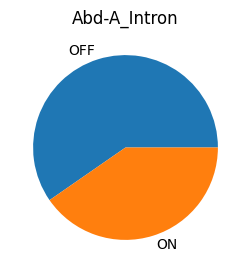

In [141]:
gene_names = transc_data.columns[1:].tolist()

fig, axs = plt.subplots(1, 1, figsize=(3, 3))

for i, gene in enumerate(gene_names):
    axs.pie(dataset[gene].value_counts(), labels=['OFF', 'ON'])
    axs.set_title(f"{gene}")


### Preprocess data

In [142]:
dataset[gene].value_counts()

Abd-A_Intron
0    167
1    113
Name: count, dtype: int64

##### Will use data from Abd-A gene, which is the gene yielding best results in paper (1641 OFF vs 653 ON)

In [143]:
dataset = pd.merge(dist_data, transc_data.iloc[:, :2], how='left', on='cellNumber').iloc[:, 1:]

X = dataset.iloc[:, :-1].to_numpy()
Y = dataset.iloc[:, -1].to_numpy()

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# Scale data
scaler = StandardScaler()

###########################
# Balance training dataset
###########################

X0 = X_train[y_train == 0]
X1 = X_train[y_train == 1]

# downsample majority class
X0_down = resample(X0, replace=False, n_samples=len(X1), random_state=42)

# combine
X_train = np.concatenate([X0_down, X1]).tolist()
y_train = np.concatenate(
    [np.zeros(len(X1), dtype=int), np.ones(len(X1), dtype=int)]
).tolist()
###########################


# Standardize
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


### Create model - use grid search for hyperparameter tuning

In [7]:
# Define parameter search
param_grid = {
    'class_weight': ['balanced'],
    'max_depth': [5, 10, 15],
    'max_features': ['sqrt', 'log2', None],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10],
    'n_estimators': [100, 150, 200, 300, 400, 500],
}

In [8]:
# Define cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [9]:
# Define model
random_forest_model = RandomForestClassifier(random_state=42)

In [10]:
# Initialize model with grid search
grid_search_random_forest_model = GridSearchCV(estimator=random_forest_model,
                                               param_grid = param_grid,
                                               cv=cv,
                                               scoring='f1_weighted',
                                               n_jobs=-1,
                                               verbose=2)

In [144]:
# Define model - avoiding hyperparameter tuning (for balanced dataset just used tuned params)
random_forest_model = RandomForestClassifier(random_state=42, class_weight='balanced',
                                             max_depth = 5, max_features = 'sqrt',
                                             min_samples_leaf = 1, n_estimators = 300)


### Fit model - using entire parameter space

In [145]:
#hist = grid_search_random_forest_model.fit(X_train, y_train)
hist = random_forest_model.fit(X_train, y_train)

### Save hyperparameter tuning results

In [ ]:
joblib.dump(grid_search_random_forest_model, "../results/random_forest_Mateo/gridsearch_results_random_forest_unfiltered.pkl")

grid_search_df = pd.DataFrame(grid_search_random_forest_model.cv_results_)
grid_search_df.to_csv("../results/random_forest_Mateo/gridsearch_results_random_forest_unfiltered.tsv", index=False, sep='\t')

In [ ]:
print('The best hyperparameters found using 5-fold cross-validation are:')
print(grid_search_random_forest_model.best_params_)

with open('../results/random_forest_Mateo/hyperparams_unfiltered.txt', 'w') as f:
    f.write('The best hyperparameters found using 5-fold cross-validation are:\n')
    for key in grid_search_random_forest_model.best_params_:
        f.write(f"{key}: {grid_search_random_forest_model.best_params_[key]}\n")

The best hyperparameters found using 5-fold cross-validation are:
{'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


### Calculate predictions and plot metrics

In [146]:
# Select best model
#best_model = grid_search_random_forest_model.best_estimator_
best_model = random_forest_model

# Calculate predictions
y_pred = best_model.predict(X_test)
y_pred_scores = best_model.predict_proba(X_test)[:,1]

# Calculate predictions on training dataset
y_pred_train = best_model.predict(X_train)
y_pred_train_scores = best_model.predict_proba(X_train)[:,1]


In [147]:
# Classification report
class_report = classification_report(y_test, y_pred)

# Confusion matrics
conf_matrix = confusion_matrix(y_test, y_pred)

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_scores)
auc = roc_auc_score(y_test, y_pred_scores)
roc_df = pd.DataFrame({'fpr': fpr, 'tpr': tpr})
roc_df.to_csv(f'../results/random_forest_Mateo/ROC_85_5000_balanced.tsv', sep='\t')

# training ROC
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_pred_train_scores)
auc_train = roc_auc_score(y_train, y_pred_train_scores)

In [148]:
# Print classification report
print(class_report)

with open('../results/random_forest_Mateo/classification_report_85_5000_balanced.txt', 'w') as f:
    f.write(class_report)

              precision    recall  f1-score   support

           0       0.72      0.55      0.62        33
           1       0.52      0.70      0.59        23

    accuracy                           0.61        56
   macro avg       0.62      0.62      0.61        56
weighted avg       0.64      0.61      0.61        56



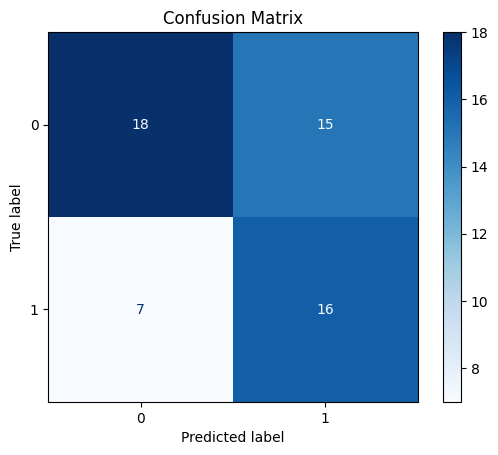

In [149]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

disp.figure_.savefig('../results/random_forest_Mateo/confusion_matrix_85_5000_balanced.pdf', format='pdf')

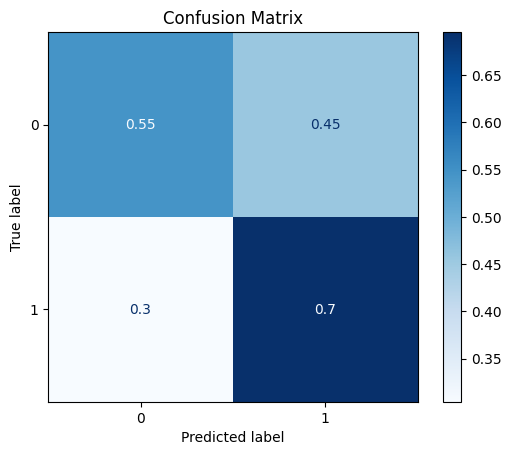

In [150]:
# Normalized confusion matrix
cm_norm = conf_matrix.astype(float) / conf_matrix.sum(axis=1)[:, None]
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

disp.figure_.savefig('../results/random_forest_Mateo/confusion_matrix_normalized_85_5000_balanced.pdf', format='pdf')

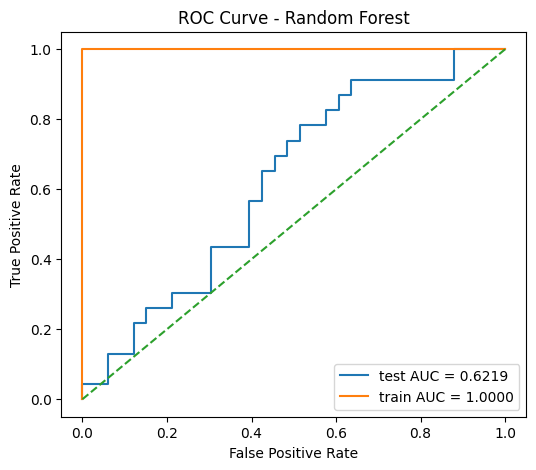

In [151]:
# ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"test AUC = {auc:.4f}")
plt.plot(fpr_train, tpr_train, label=f"train AUC = {auc_train:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.savefig('../results/random_forest_Mateo/ROC_85_5000_balanced.pdf', format='pdf')

In [152]:
# Get feture importances
n_feats = 20
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1][:n_feats]
features = dataset.columns[:-1]

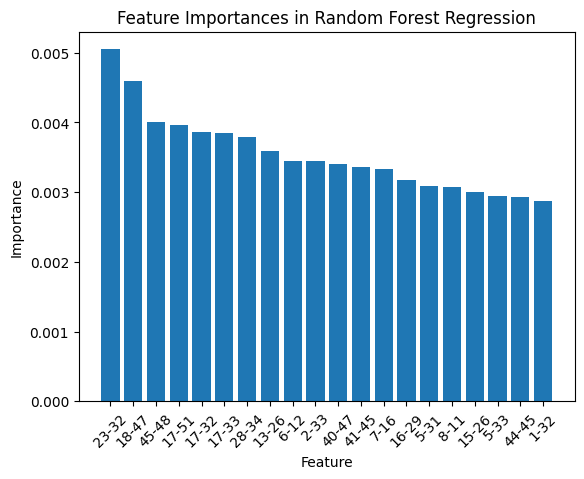

In [153]:
# Plot feature importances
plt.bar(range(n_feats), importances[indices],  align="center")
plt.xticks(range(n_feats), [features[i] for i in indices], rotation=45)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importances in Random Forest Regression")

plt.savefig('../results/random_forest_Mateo/feature_importance_85_5000_balanced.pdf', format='pdf')